In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
path1 = '../../data/net_data/原始数据/10_16_2015_Initial capacity_SP20-1.xlsx'
path2 = '../../data/net_data/原始数据/11_5_2015_low current OCV test_SP20-1.xlsx'
path3 = '../../data/net_data/原始数据/12_2_2015_Incremental OCV test_SP20-1.xlsx'

低电流OCV测试
采用小电流（如C/20、C/25）对电池进行充放电，使对应的端电压近似为OCV。测试执行步骤为：
1. 以 1 C 速率恒流充电至截止电压 4.2 V
2. 恒压充电，直至电流降至0.01C
3. 现在以 C/20 恒定速率放电，直到电压降至 2.5 V
4. 以 C/20 恒定速率完全充电至 4.2 V
5. 0℃、25℃和45℃下充电和放电过程的平均电压记录为OCV。

In [54]:
#读取初始容量数据
data = pd.read_excel(path1)

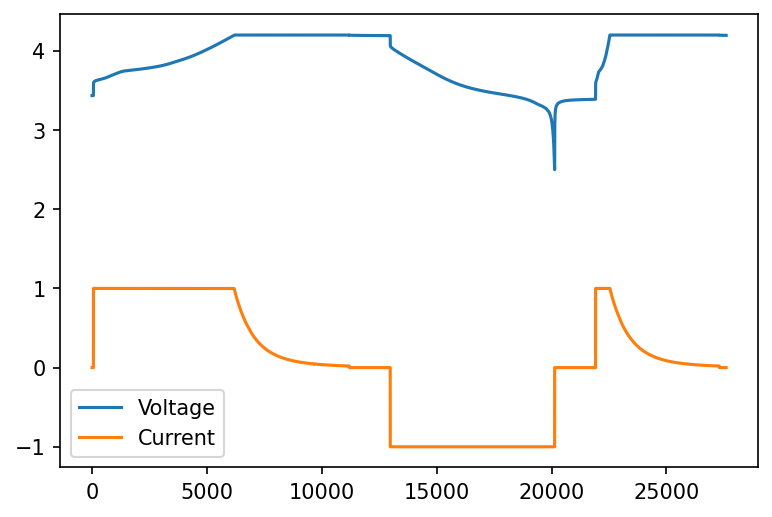

In [55]:
#查看电压电流变化情况
ui_columns = ['Voltage(V)', 'Current(A)']
ui_data = data.loc[:, ui_columns].values
plt.figure(dpi=150)
plt.plot(ui_data[:, 0], label='Voltage')
plt.plot(ui_data[:, 1], label='Current')
plt.legend()
plt.show()

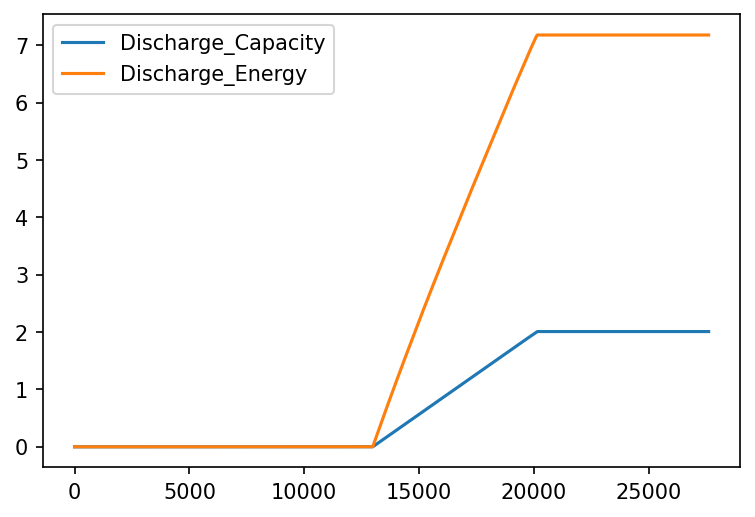

In [72]:
dis_cap = data.loc[:, 'Discharge_Capacity(Ah)'].values
dis_ene = data.loc[:, 'Discharge_Energy(Wh)'].values
plt.figure(dpi=150)
plt.plot(dis_cap, label='Discharge_Capacity')
plt.plot(dis_ene, label='Discharge_Energy')
plt.legend()
plt.show()

In [74]:
cap = dis_cap[-1]
ene = dis_ene[-1]
print(cap)
print(ene)
print(cap / ene)

2.009444140560707
7.179246865810065
0.2798962311952721


In [56]:
# 读取增量ocv数据
df1 = pd.read_excel(path3, sheet_name='Channel_1-005_1')
df2 = pd.read_excel(path3, sheet_name='Channel_1-005_2')
df3 = pd.read_excel(path3, sheet_name='Channel_1-005_3')

# 去除重复的行
df2 = df2.drop(0)  # 假设重复的行是第一行
df3 = df3.drop(0)  # 假设重复的行是第一行

# 将三个子表按行（轴0）方向进行拼接
combined_df = pd.concat([df1, df2, df3], axis=0)

# 重置索引
combined_df = combined_df.reset_index(drop=True)

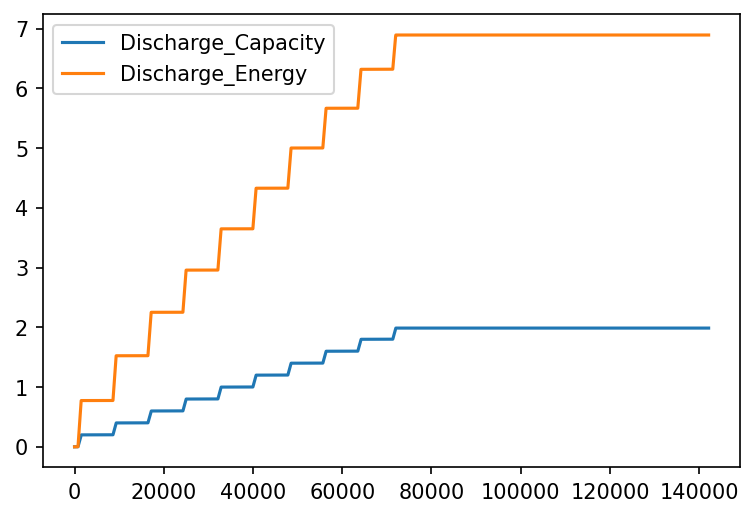

In [75]:
dis_cap = combined_df.loc[:, 'Discharge_Capacity(Ah)'].values
dis_ene = combined_df.loc[:, 'Discharge_Energy(Wh)'].values
plt.figure(dpi=150)
plt.plot(dis_cap, label='Discharge_Capacity')
plt.plot(dis_ene, label='Discharge_Energy')
plt.legend()
plt.show()

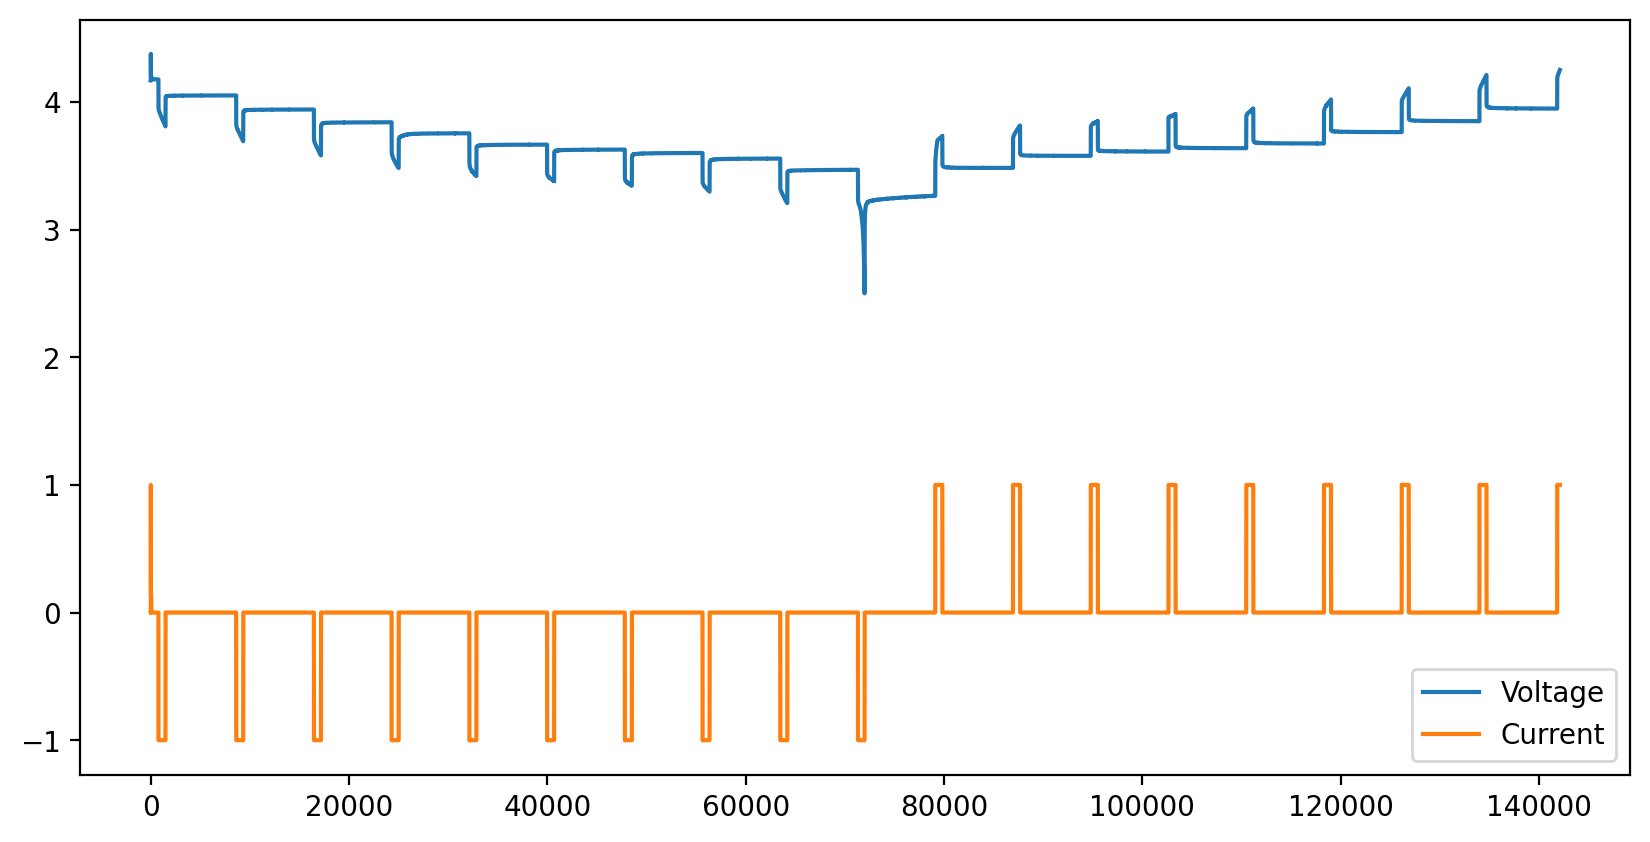

In [109]:
#查看电压电流变化情况
ui_columns = ['Voltage(V)', 'Current(A)']
ui_data = combined_df.loc[:, ui_columns].values
plt.figure(dpi=200, figsize=(10, 5))
plt.plot(ui_data[:, 0], label='Voltage')
plt.plot(ui_data[:, 1], label='Current')
plt.legend()
plt.show()

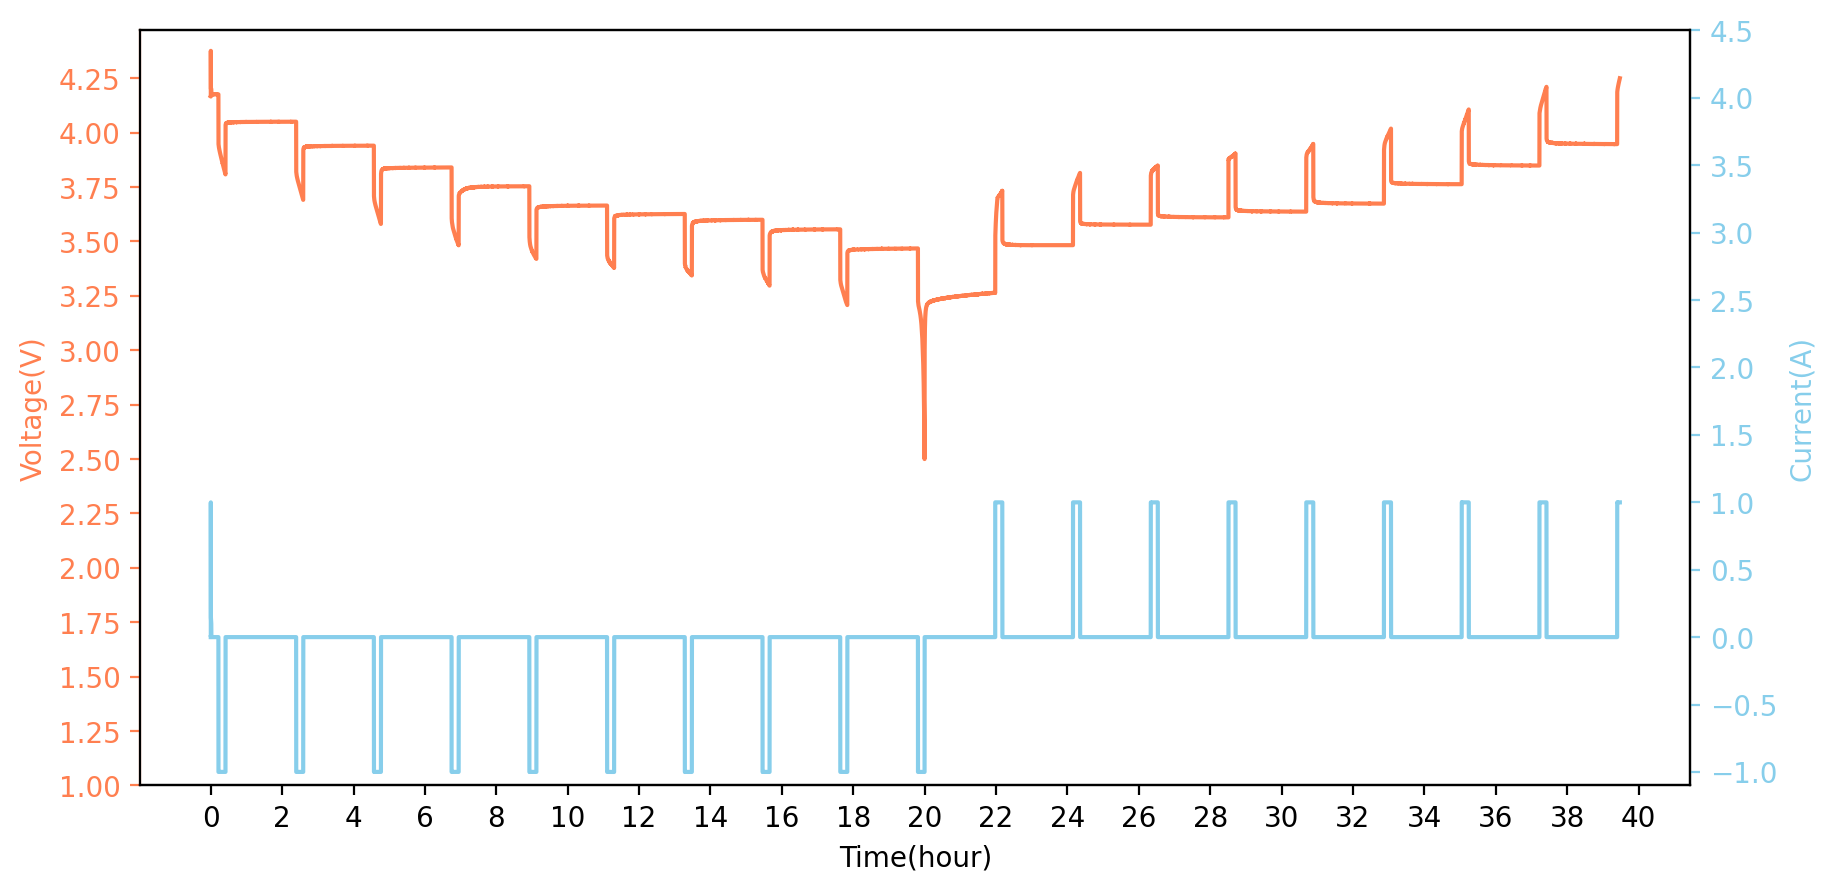

In [139]:
# 示例数据
x = [1, 2, 3, 4, 5]
y1 = [10, 20, 30, 40, 50]
y2 = [5, 15, 25, 35, 45]

# 创建图形和轴对象
fig, ax1 = plt.subplots(dpi=200, figsize = (10,5))

# 绘制第一条曲线
ax1.plot(ui_data[:, 0], color=(255/255, 127/255, 80/255))
ax1.set_ylabel('Voltage(V)', color=(255/255, 127/255, 80/255))
ax1.spines['left'].set_color((255/255, 127/255, 80/255))
ax1.set(yticks=np.arange(1, 4.5, 0.25))
ax1.tick_params(axis='y', colors=(255/255, 127/255, 80/255))
ax1.set(xlabel='Time(hour)', xticks=np.arange(0,151200, 7200), xticklabels=np.arange(0, 41, 2))

# 创建共享横坐标轴的副图
ax2 = ax1.twinx()

# 绘制第二条曲线
ax2.plot(ui_data[:, 1], color=(135/255, 206/255, 235/255))
ax2.set_ylabel('Current(A)', color=(135/255, 206/255, 235/255))
ax2.tick_params(axis='y', colors=(135/255, 206/255, 235/255))
ax2.set(yticks=np.arange(-1, 5, 0.5))

# 显示图形
fig.savefig('../../doc/pictures/ui.png')
plt.show()

In [76]:
cha_cap = combined_df.loc[:, 'Charge_Capacity(Ah)'].values
cha_ene = combined_df.loc[:, 'Charge_Energy(Wh)'].values

In [87]:
initial_soc = 1
soc_cap = (initial_soc + (cha_cap - dis_cap)/cap) * 100
soc_ene = (initial_soc + (cha_ene - dis_ene)/ene) * 100

In [88]:
cha_cap[-1]

1.69230688135793

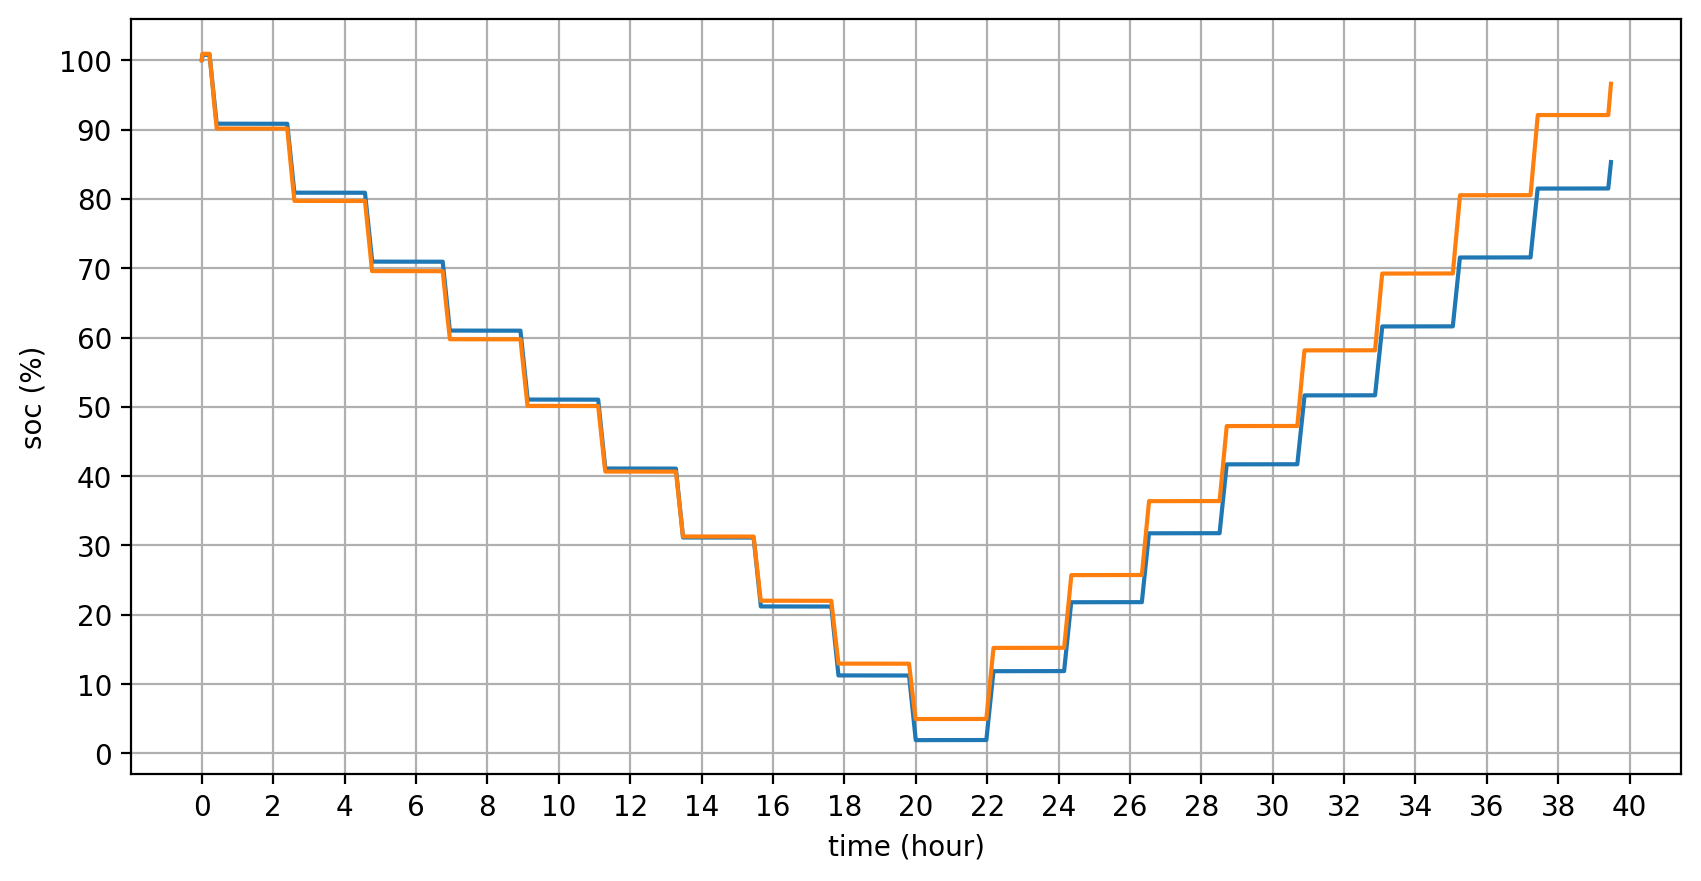

In [115]:
fig, ax = plt.subplots(dpi=200, figsize=(10, 5))
ax.plot(soc_cap)
ax.plot(soc_ene)

ax.set(xlabel='time (hour)', ylabel='soc (%)', xticks=np.arange(0,151200, 7200), xticklabels=np.arange(0, 41, 2),
      yticks=np.arange(0, 110, 10))
ax.grid()
fig.savefig('../../doc/pictures/soc.png')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


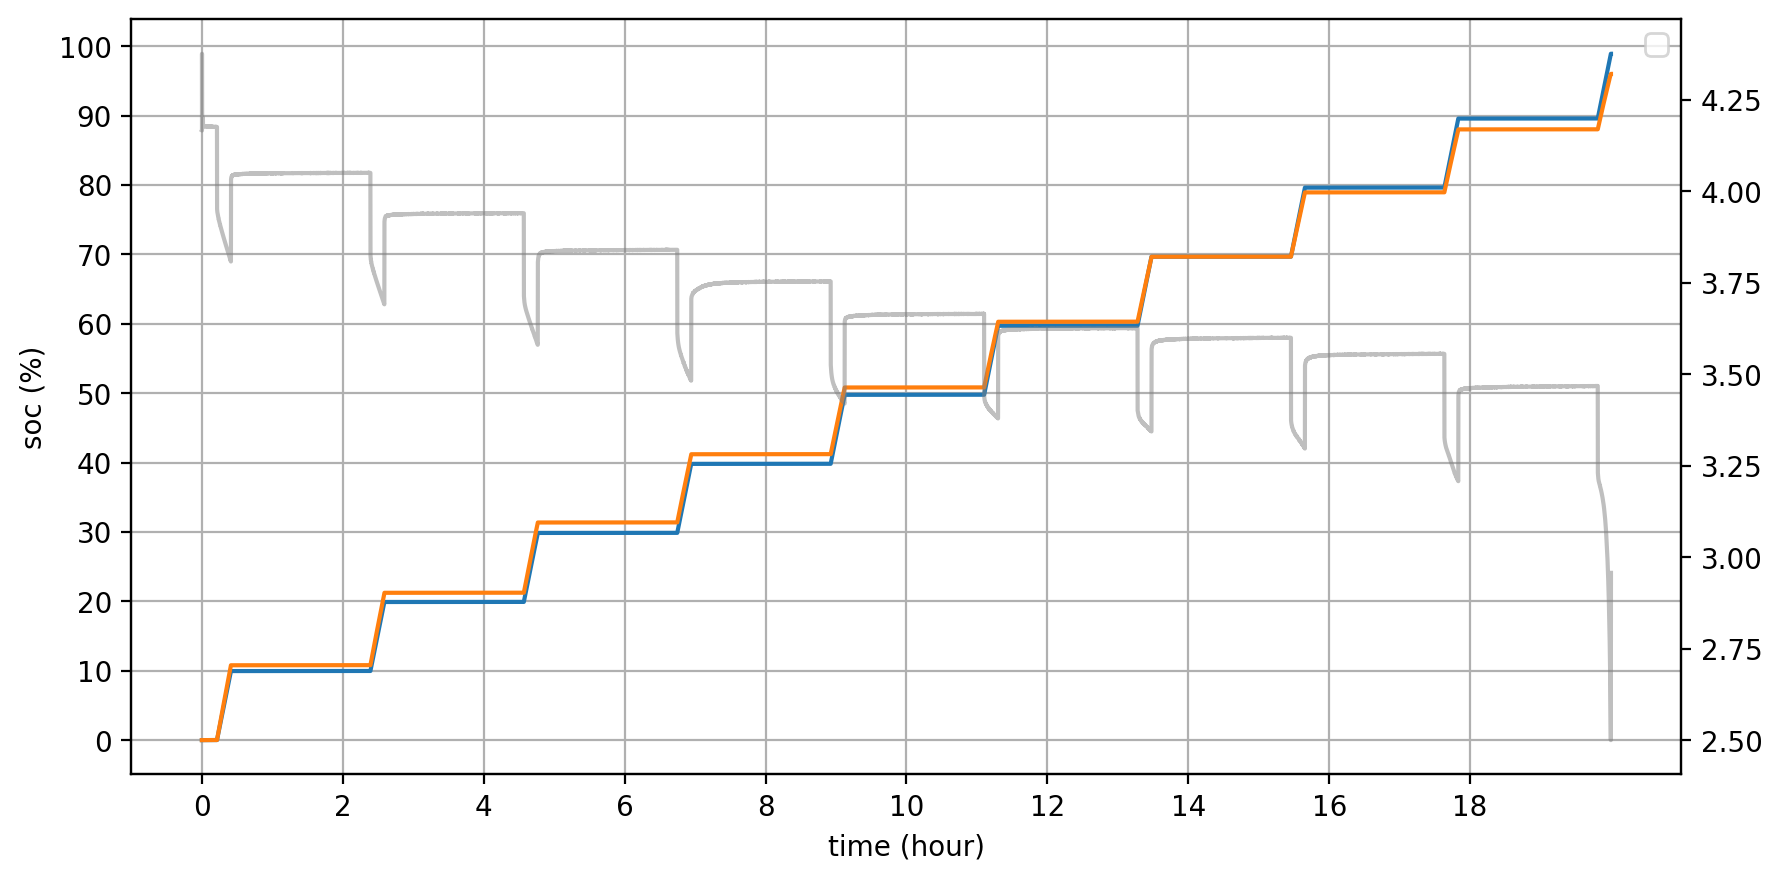

In [150]:
fig, ax = plt.subplots(dpi=200, figsize=(10, 5))
ax.plot((dis_cap * 100 / cap)[:72000], label='soc')
ax.plot((dis_ene * 100 / ene)[:72000], label='ene')

ax2 = ax.twinx()
ax2.plot(ui_data[:72000, 0], color='grey', alpha=0.5)

ax.set(xlabel='time (hour)', ylabel='soc (%)', xticks=np.arange(0,72000, 7200), xticklabels=np.arange(0, 20, 2),
      yticks=np.arange(0, 110, 10))
ax.grid()
fig.savefig('../../doc/pictures/soc.png')
plt.legend()
plt.show()

In [152]:
dis_cap.shape

(142119,)

/Users/pyiwen/mambaforge/envs/nb/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26609 (\N{CJK UNIFIED IDEOGRAPH-67F1}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pyiwen/mambaforge/envs/nb/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pyiwen/mambaforge/envs/nb/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pyiwen/mambaforge/envs/nb/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pyiwen/mambaforge/envs/nb/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 263

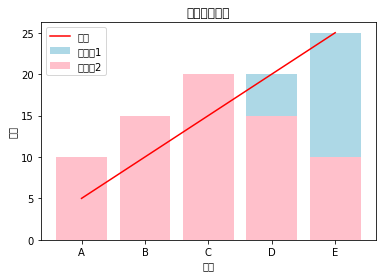

In [153]:
# 示例数据
categories = ['A', 'B', 'C', 'D', 'E']
values1 = [5, 10, 15, 20, 25]
values2 = [10, 15, 20, 15, 10]
x = np.arange(len(categories))

# 创建图形和轴对象
fig, ax = plt.subplots()

# 绘制第一个柱状图
ax.bar(x, values1, color='lightblue', label='柱状图1')

# 绘制第二个柱状图
ax.bar(x, values2, color='pink', label='柱状图2')

# 绘制曲线
ax.plot(x, values1, color='red', label='曲线')

# 设置图例
ax.legend()

# 设置图形标题和轴标签
ax.set_title('柱状图和曲线')
ax.set_xlabel('分类')
ax.set_ylabel('数值')

# 设置x轴刻度标签
ax.set_xticks(x)
ax.set_xticklabels(categories)

# 显示图形
plt.show()

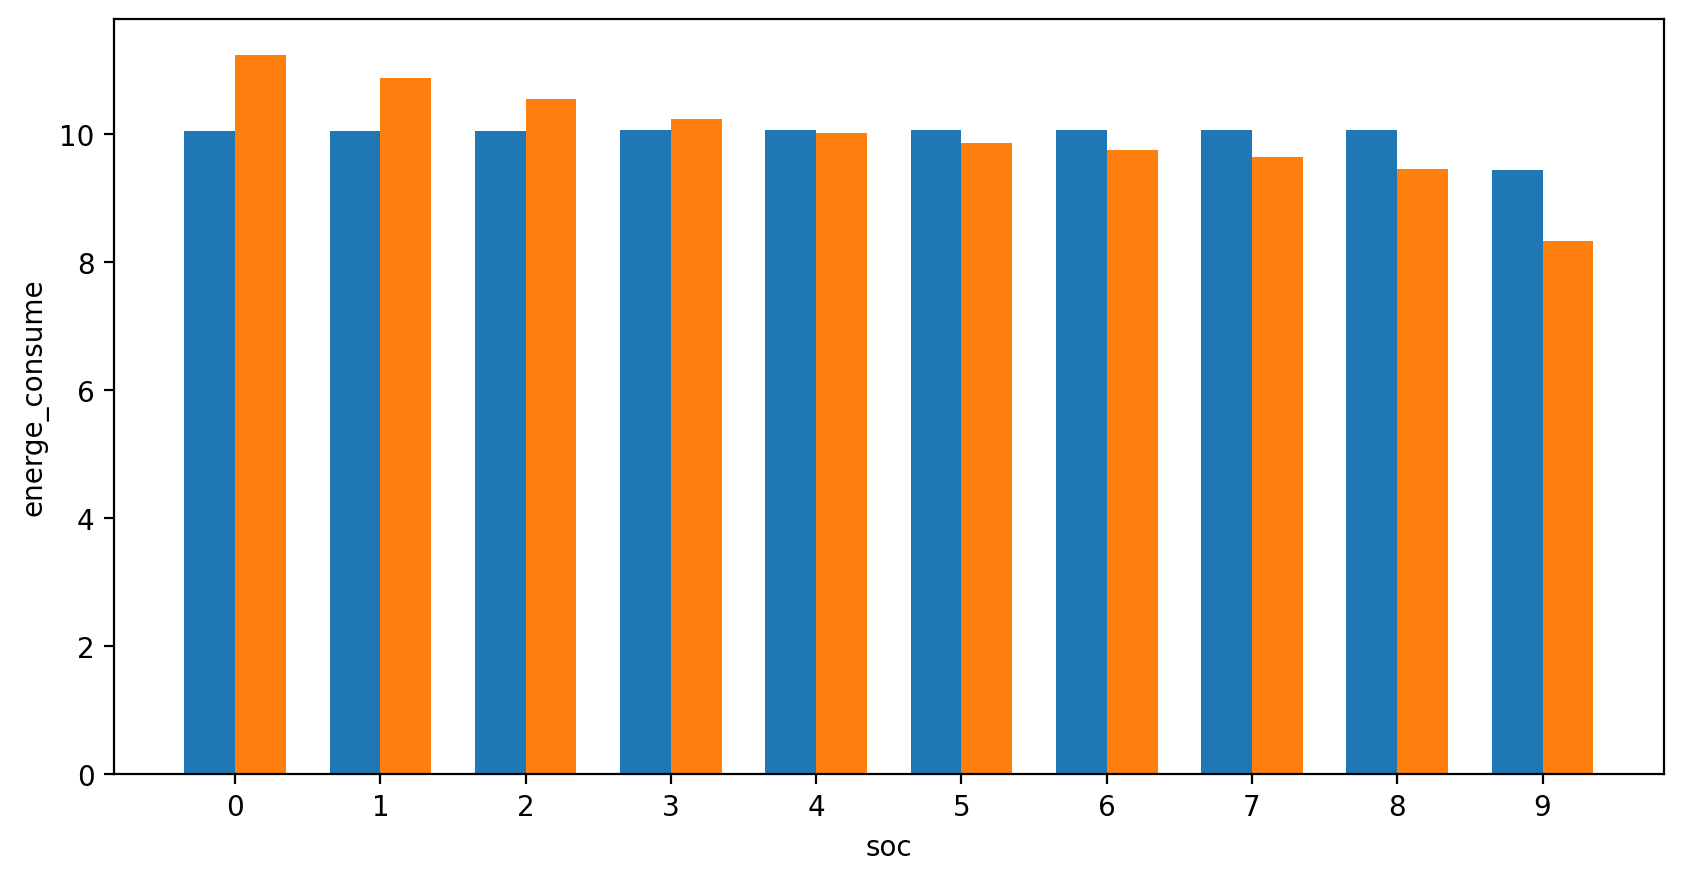

In [183]:
import matplotlib.pyplot as plt
import numpy as np

# 示例数据
categories = ['A', 'B', 'C', 'D', 'E']
values1 = dis_cap_bar
values2 = dis_ene_bar
x = np.arange(len(values1))

# 创建图形和轴对象
fig, ax = plt.subplots(figsize=(10,5), dpi=200)

# 设置柱状图宽度
bar_width = 0.35

# 绘制第一个柱状图
ax.bar(x - bar_width/2, values1, width=bar_width)

# 绘制第二个柱状图，稍微调整位置
ax.bar(x + bar_width/2, values2, width=bar_width)


# 设置图形标题和轴标签
ax.set_xlabel('soc')
ax.set_ylabel('energe_consume')

# 设置x轴刻度标签
ax.set_xticks(x)

# 显示图形
plt.show()

In [182]:
dis_cap_bar = []
dis_ene_bar = []
for i in range(1, 11):
    if i==0:
        dis_cap_bar.append(dis_cap[7560 * i])
        dis_ene_bar.append(dis_ene[7560 * i])
    else:
        dis_cap_bar.append(dis_cap[7560 * i] - dis_cap[7560*(i-1)])
        dis_ene_bar.append(dis_ene[7560 * i] - dis_ene[7560*(i-1)])
dis_cap_bar = dis_cap_bar / (dis_cap[-1] / 100)
dis_ene_bar = dis_ene_bar / (dis_ene[-1] / 100)